In [3]:
# Monte Carlo Simulation: Investment Returns 
#Allocating Resources between two Assets

# Investment problem

#You have R1000 now and need to pay R1050 in one year. You have two assets available: A risk free asset that returns 3% and a stock that returns 10%
#with 20% standard diviation. How mush should you invest in the two assets to maximize your probability of having at least R1050 in a year?



In [4]:
# Bulidng Basic modewl which handles single set of inputs to produce a single set of outputs. In this case wen will have 
# to built it for a given return of each assets.

# 1. PortFolio Returns (rp) -- It matters what weight we have to invest in each of the assets, as well as each of the asset's returns.
#This is just one perroid model, therefore rp = rrwrf+ rsws
# Two assets to be fully invested Wrf + Ws =1
# rp = rrf(1-Ws) + rfWs


In [5]:
stock_ret =0.1
rf=0.03
stock_weight = 0.5

portfolio_ret = rf*(1-stock_weight) + stock_ret * stock_weight
portfolio_ret

0.065

In [6]:
# appyling the return to our initial portfolio value to get final portfolio value

In [7]:
portfolio_initial_value = 1000

portfolio_end_value = portfolio_initial_value*(1+portfolio_ret)
portfolio_end_value

1065.0

In [8]:
# Wrapping up into one function that will represent the model

In [9]:
def port_end_value(stock_ret=0.1,rf = 0.03, stock_weight=0.5,portfolio_initial_value=1000):
    portfolio_ret = rf * (1 - stock_weight) + stock_ret * stock_weight
    portfolio_end_value = portfolio_initial_value*(1+ portfolio_ret)
    return portfolio_end_value

port_end_value()

1065.0

In [10]:
# Our model works fine. 

In [11]:
# Monte Carlo Simulation
#  - Draw inputs from distribution (Randomly picking values)
#  We will assume that the stock's returns are normally distributed. 

In [12]:
import random

stock_mean = 0.1
stock_std = 0.2

random.normalvariate(stock_mean,stock_std)

0.0071726006772192125

In [13]:
# see the above choose different returns each time. This is what we need to pass into our model each time.


In [14]:
 # Run the MOdel
# Rather than taking stock retrun a fixed leta run the model using randomly frawn stock retrun

stock_ret = random.normalvariate(stock_mean,stock_std)
print(f'running with stock return {stock_ret:.1%}')
port_end_value(stock_ret)

running with stock return -9.1%


969.3230963407009

In [15]:
# run aboove multiple times to see what we will get a diferent portloio end value each time. 

In [16]:
# Collect Outputs
# We just need to run the above as a loop, and apeending the result as a list each time we run the model.

In [17]:
n_iter = 5
outputs = []
for i in range(n_iter):
    stock_ret = random.normalvariate(stock_mean,stock_std)
    result = port_end_value(stock_ret)
    outputs.append(result)
outputs    

[1192.1657633241507,
 1084.0897671842254,
 889.5119827530373,
 1066.613362198182,
 1196.9494341273157]

In [18]:
# Create a funtion for the above.


In [19]:
def port_end_value_simulations(stock_mean = 0.1,stock_std = 0.2,stock_weight =0.5,n_iter = 1000):
    outputs = []
    for i in range(n_iter):
        stock_ret = random.normalvariate(stock_mean,stock_std)
        result = port_end_value(stock_ret,stock_weight =stock_weight)
        outputs.append(result)
    return outputs  
    
results = port_end_value_simulations()
print(f'There are {len(results)} results. Fisrt five:')
results[:5]

There are 1000 results. Fisrt five:


[1061.6578388499684,
 1180.863377288145,
 970.9910589231793,
 1022.8578749582624,
 1083.7965079095104]

In [20]:
# Analyze the Outputs

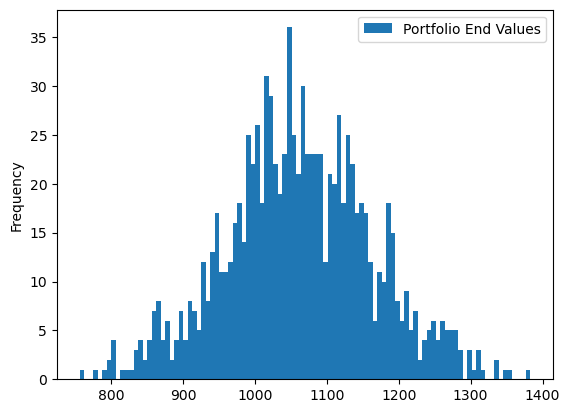

In [21]:
import matplotlib.pyplot as plt
#%matplotlib inline
import pandas as pd

df= pd.DataFrame()
df['Portfolio End Values'] = results
df.plot.hist(bins=100)
plt.show()

In [22]:
# Probalility Outputs
# we would like to see two results 1- a table of probabilities 2- Results which is achieved at that probability in the distribution

In [23]:
percentiles = [i/20 for i in range(1,20)]
percentiles

[0.05,
 0.1,
 0.15,
 0.2,
 0.25,
 0.3,
 0.35,
 0.4,
 0.45,
 0.5,
 0.55,
 0.6,
 0.65,
 0.7,
 0.75,
 0.8,
 0.85,
 0.9,
 0.95]

In [24]:
df.quantile(percentiles)

,Portfolio End Values
0.05,882.977628
0.10,933.210768
0.15,958.603308
0.20,978.867948
0.25,996.090291
0.30,1008.769622
0.35,1021.244241
0.40,1035.308066
0.45,1047.452904
0.50,1058.868030


In [25]:
# Probability of Archieving Our Objective

In [26]:
(df['Portfolio End Values'] >=1050).astype(int).mean()

np.float64(0.533)

In [27]:
df['Portfolio End Values'] >=1050

0       True
1       True
2      False
3      False
4       True
       ...  
995    False
996    False
997     True
998    False
999     True
Name: Portfolio End Values, Length: 1000, dtype: bool

In [28]:
(df['Portfolio End Values'] >=1050).astype(int)

0      1
1      1
2      0
3      0
4      1
      ..
995    0
996    0
997    1
998    0
999    1
Name: Portfolio End Values, Length: 1000, dtype: int64

In [29]:
# 1 is greater 0 is below. Average of this will produce the probability

In [30]:
# Combining Visualization and Probabilities Together


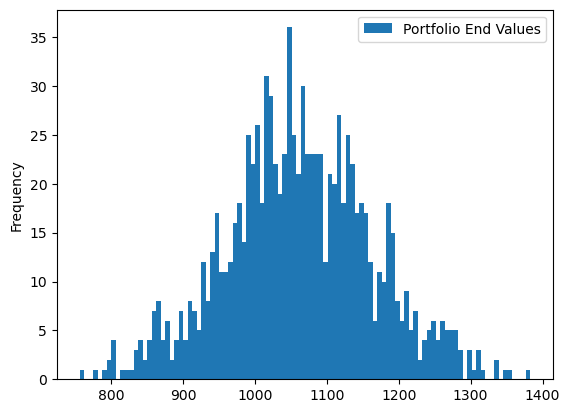

Probability Table
0.05     R882.98
0.10     R933.21
0.15     R958.60
0.20     R978.87
0.25     R996.09
0.30    R1008.77
0.35    R1021.24
0.40    R1035.31
0.45    R1047.45
0.50    R1058.87
0.55    R1070.75
0.60    R1083.90
0.65    R1100.68
0.70    R1116.71
0.75    R1129.55
0.80    R1144.71
0.85    R1167.65
0.90    R1193.10
0.95    R1240.72
Name: Portfolio End Values, dtype: object

Probability of getting R1,050 in cash: 53.3%



In [31]:
def create_dataframe_from_results(results):
    df= pd.DataFrame()
    df['Portfolio End Values'] = results
    return df

def visualize_results(df):
    df.plot.hist(bins=100)
    plt.show()

def probability_table(df):
    percentiles = [i/20 for i in range(1,20)]
    return df['Portfolio End Values'].quantile(percentiles)

def probability_of_objective(df,desired_cash =1050):
    return (df['Portfolio End Values'] >= desired_cash).astype(int).mean()

def model_outputs(results,desired_cash =1050):
    df = create_dataframe_from_results(results)
    visualize_results(df)
    prob_table= probability_table(df)
    prob_objective = probability_of_objective(df,desired_cash=desired_cash)
    return prob_table,prob_objective

def display_model_summary(results,desired_cash=1050):
    prob_table,prob_objective = model_outputs(results,desired_cash=desired_cash)
    print('Probability Table')
    print(prob_table.apply(lambda x: f'R{x:.2f}'))
    print('')
    print(f'Probability of getting R{desired_cash:,.0f} in cash: {prob_objective:.1%}')
    print('')

display_model_summary(results)
    
    

In [32]:
# Choosing The Appropriate Weights
# we want to evaluate wights from 10% to 90% in 10% increments 

In [33]:
from IPython.display import HTML, display

In [34]:
def display_header(header):
    return display(HTML(f'<h2>{header}</h2>'))


In [35]:
weights  = [i/10 for i in range(1,10)]
weights

[0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9]

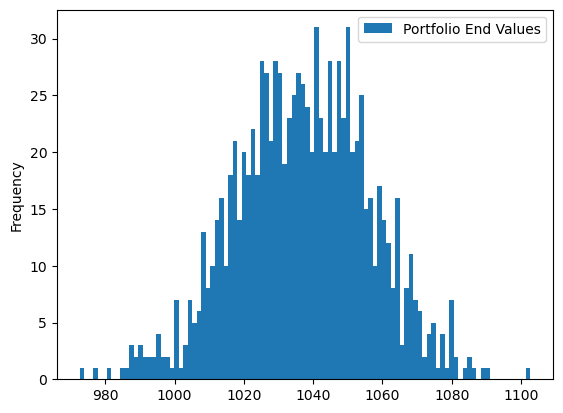

Probability Table
0.05    R1006.10
0.10    R1012.71
0.15    R1017.13
0.20    R1020.69
0.25    R1023.84
0.30    R1026.35
0.35    R1029.34
0.40    R1032.00
0.45    R1034.75
0.50    R1037.09
0.55    R1040.02
0.60    R1042.42
0.65    R1045.12
0.70    R1047.74
0.75    R1050.36
0.80    R1053.31
0.85    R1056.68
0.90    R1061.64
0.95    R1068.61
Name: Portfolio End Values, dtype: object

Probability of getting R1,050 in cash: 26.2%



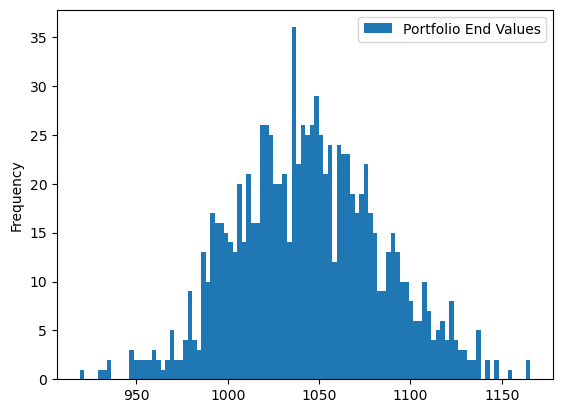

Probability Table
0.05     R983.37
0.10     R994.53
0.15    R1002.22
0.20    R1010.01
0.25    R1016.95
0.30    R1022.10
0.35    R1027.20
0.40    R1034.10
0.45    R1037.82
0.50    R1043.12
0.55    R1048.09
0.60    R1052.52
0.65    R1058.95
0.70    R1064.54
0.75    R1070.83
0.80    R1077.01
0.85    R1086.77
0.90    R1096.02
0.95    R1111.86
Name: Portfolio End Values, dtype: object

Probability of getting R1,050 in cash: 42.6%



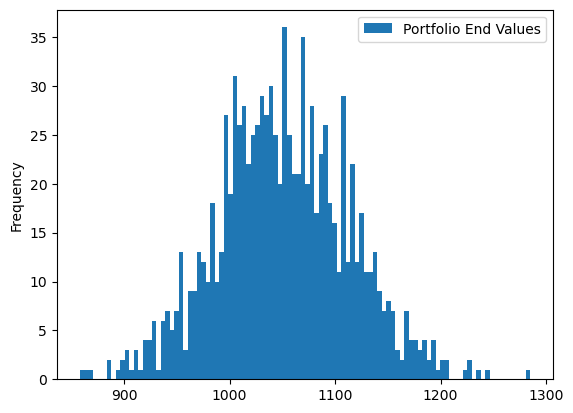

Probability Table
0.05     R948.13
0.10     R972.65
0.15     R989.07
0.20     R999.81
0.25    R1008.54
0.30    R1016.58
0.35    R1025.80
0.40    R1033.25
0.45    R1040.50
0.50    R1049.79
0.55    R1057.28
0.60    R1066.55
0.65    R1074.58
0.70    R1083.46
0.75    R1092.44
0.80    R1105.86
0.85    R1116.05
0.90    R1131.12
0.95    R1153.13
Name: Portfolio End Values, dtype: object

Probability of getting R1,050 in cash: 49.9%



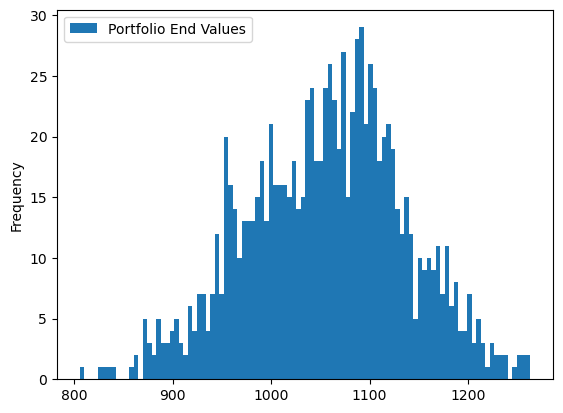

Probability Table
0.05     R922.62
0.10     R953.12
0.15     R967.47
0.20     R986.15
0.25     R999.88
0.30    R1013.48
0.35    R1027.39
0.40    R1039.66
0.45    R1051.73
0.50    R1061.13
0.55    R1071.57
0.60    R1081.93
0.65    R1090.79
0.70    R1100.07
0.75    R1110.61
0.80    R1121.59
0.85    R1136.56
0.90    R1159.63
0.95    R1186.11
Name: Portfolio End Values, dtype: object

Probability of getting R1,050 in cash: 55.4%



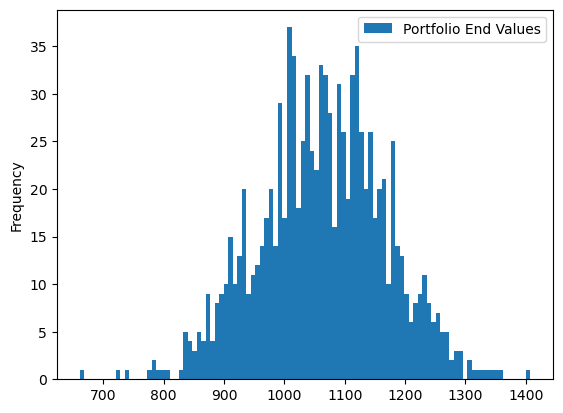

Probability Table
0.05     R891.50
0.10     R924.98
0.15     R952.47
0.20     R975.93
0.25     R995.72
0.30    R1010.18
0.35    R1023.79
0.40    R1037.26
0.45    R1052.62
0.50    R1064.67
0.55    R1077.16
0.60    R1093.01
0.65    R1109.26
0.70    R1121.38
0.75    R1133.88
0.80    R1149.02
0.85    R1171.10
0.90    R1194.34
0.95    R1235.15
Name: Portfolio End Values, dtype: object

Probability of getting R1,050 in cash: 55.4%



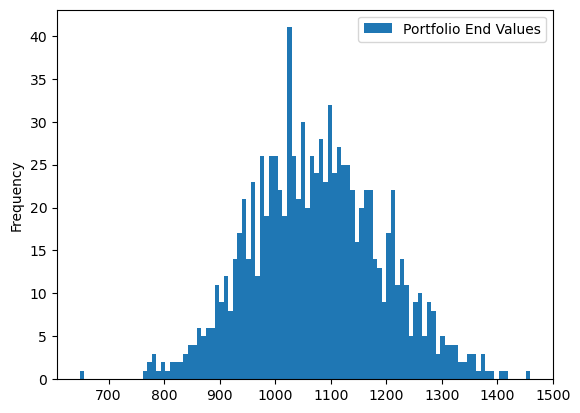

Probability Table
0.05     R890.68
0.10     R929.99
0.15     R953.01
0.20     R974.41
0.25     R992.14
0.30    R1009.78
0.35    R1025.11
0.40    R1039.03
0.45    R1054.80
0.50    R1072.74
0.55    R1088.73
0.60    R1102.02
0.65    R1117.38
0.70    R1133.24
0.75    R1153.42
0.80    R1174.51
0.85    R1204.67
0.90    R1229.52
0.95    R1277.06
Name: Portfolio End Values, dtype: object

Probability of getting R1,050 in cash: 56.5%



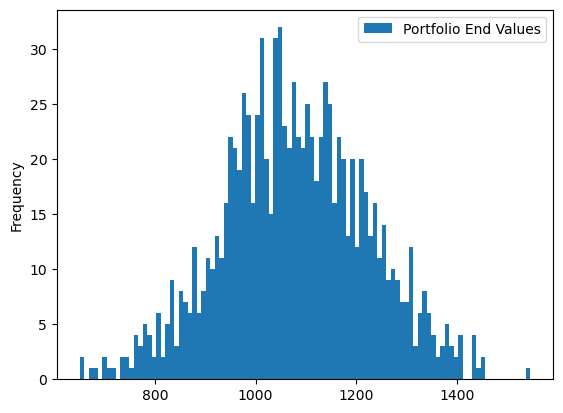

Probability Table
0.05     R834.61
0.10     R897.11
0.15     R938.63
0.20     R961.09
0.25     R981.41
0.30    R1003.44
0.35    R1019.41
0.40    R1041.30
0.45    R1056.29
0.50    R1075.20
0.55    R1094.87
0.60    R1114.13
0.65    R1135.02
0.70    R1152.26
0.75    R1174.70
0.80    R1204.45
0.85    R1229.99
0.90    R1266.73
0.95    R1322.59
Name: Portfolio End Values, dtype: object

Probability of getting R1,050 in cash: 56.3%



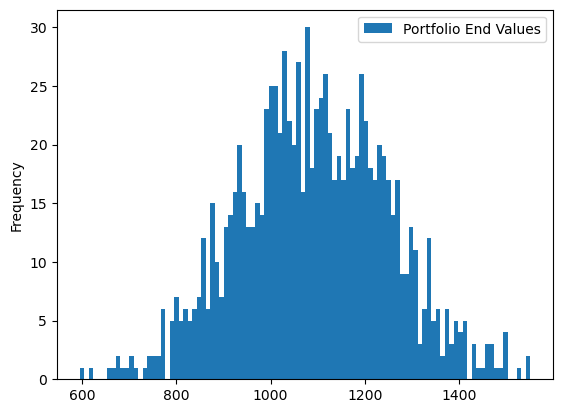

Probability Table
0.05     R829.83
0.10     R884.07
0.15     R926.32
0.20     R954.90
0.25     R987.45
0.30    R1006.53
0.35    R1025.97
0.40    R1045.91
0.45    R1067.51
0.50    R1090.11
0.55    R1111.06
0.60    R1131.46
0.65    R1158.48
0.70    R1181.72
0.75    R1203.50
0.80    R1228.68
0.85    R1253.51
0.90    R1292.97
0.95    R1352.13
Name: Portfolio End Values, dtype: object

Probability of getting R1,050 in cash: 59.1%



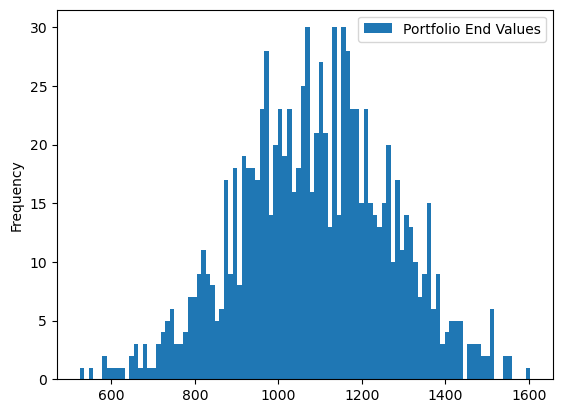

Probability Table
0.05     R787.45
0.10     R851.67
0.15     R898.16
0.20     R936.22
0.25     R964.34
0.30     R990.41
0.35    R1014.37
0.40    R1042.68
0.45    R1066.83
0.50    R1092.64
0.55    R1112.59
0.60    R1139.11
0.65    R1164.94
0.70    R1184.22
0.75    R1212.79
0.80    R1247.91
0.85    R1282.44
0.90    R1324.53
0.95    R1382.87
Name: Portfolio End Values, dtype: object

Probability of getting R1,050 in cash: 58.8%



In [36]:
for weight in weights:
    display_header(f'Results with {weight:.0%} in the stock')
    results = port_end_value_simulations(stock_weight=weight)
    display_model_summary(results)

In [38]:
display_header("Conclusion")
display(HTML("<p>The Probability of reaching our desired cash increases as weight in stock increases. this means that with a higher weight in stock, it is more likey to earn more money. This decision is based on a manager's risk tolarence, but lower than 50% in stock would be a bad choise due to lower probability of hhiting the objective.</p>"))